# Phase 2: EDA is where the data starts telling a story. We'll build these visualizations in order:

## Load the Data

In [5]:
import pandas as pd
df = pd.read_csv("loan_applicants_clean.csv")

## 1. Distribution plots — income, loan amount, age (understand the shape of your data)

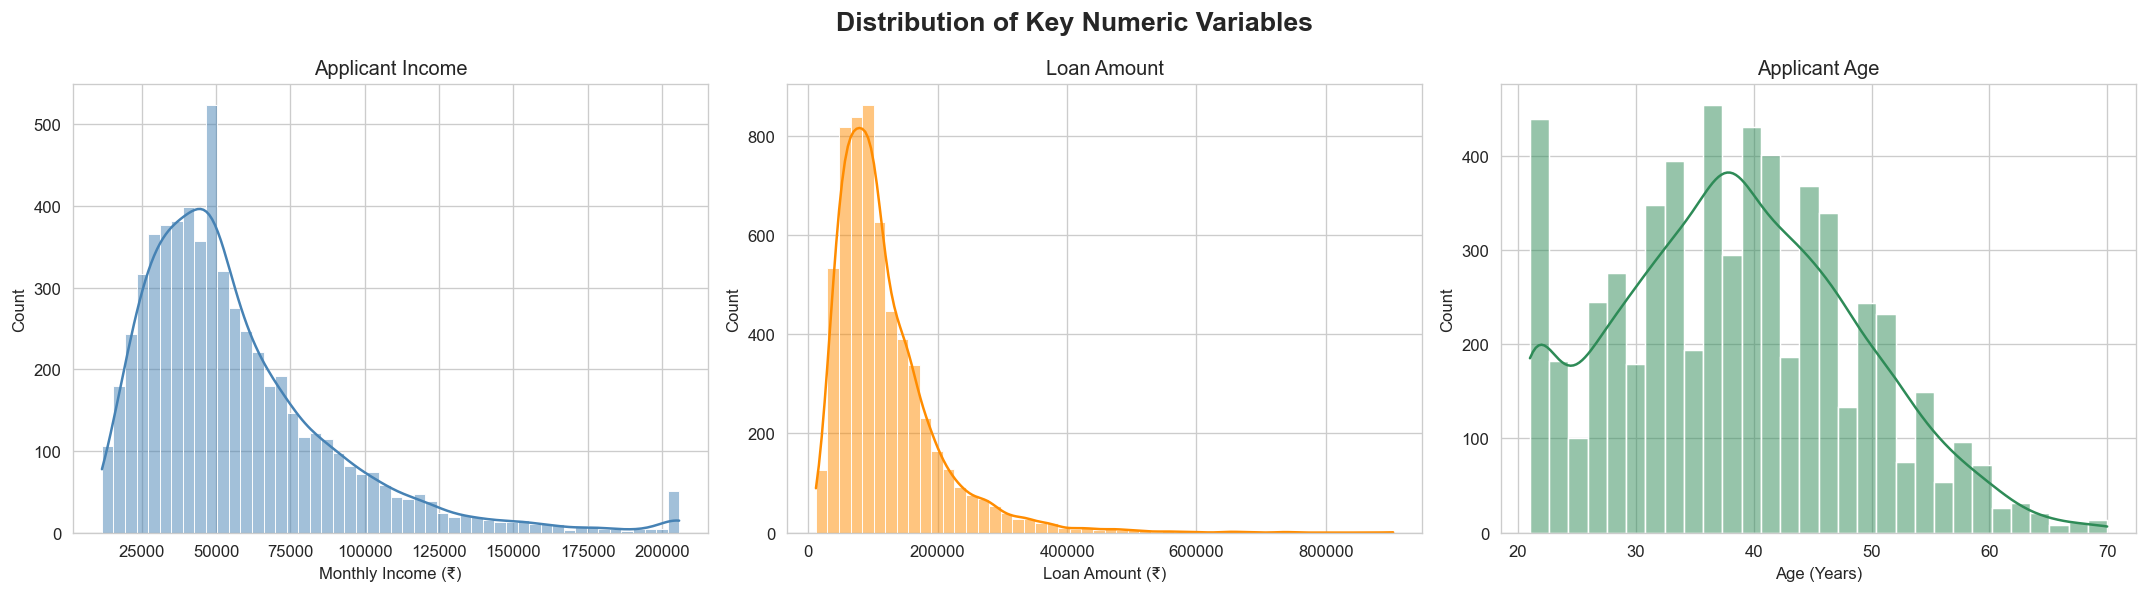

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120 # rc - runtime configuration , dpi - dots per inch

# ---- Plot 1: Distributions of key numeric columns ----
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
fig.suptitle("Distribution of Key Numeric Variables", fontsize = 16, fontweight = "bold")

# Income Distribution
sns.histplot(df["applicant_income"], bins = 50, kde = True, color = "steelblue", ax = axes[0])
axes[0].set_title("Applicant Income")
axes[0].set_xlabel("Monthly Income (₹)")
axes[0].set_ylabel("Count")

# Loan Distribution
sns.histplot(df["loan_amount"], bins = 50, kde = True, color = "darkorange", ax = axes[1])
axes[1].set_title("Loan Amount")
axes[1].set_xlabel("Loan Amount (₹)")
axes[1].set_ylabel("Count")

# Age Distribution
sns.histplot(df["age"], bins = 30, kde = True, color = "seagreen", ax = axes[2])
axes[2].set_title("Applicant Age")
axes[2].set_xlabel("Age (Years)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 2. Default rate by category — by region, employment type, credit history, education (bar plots)

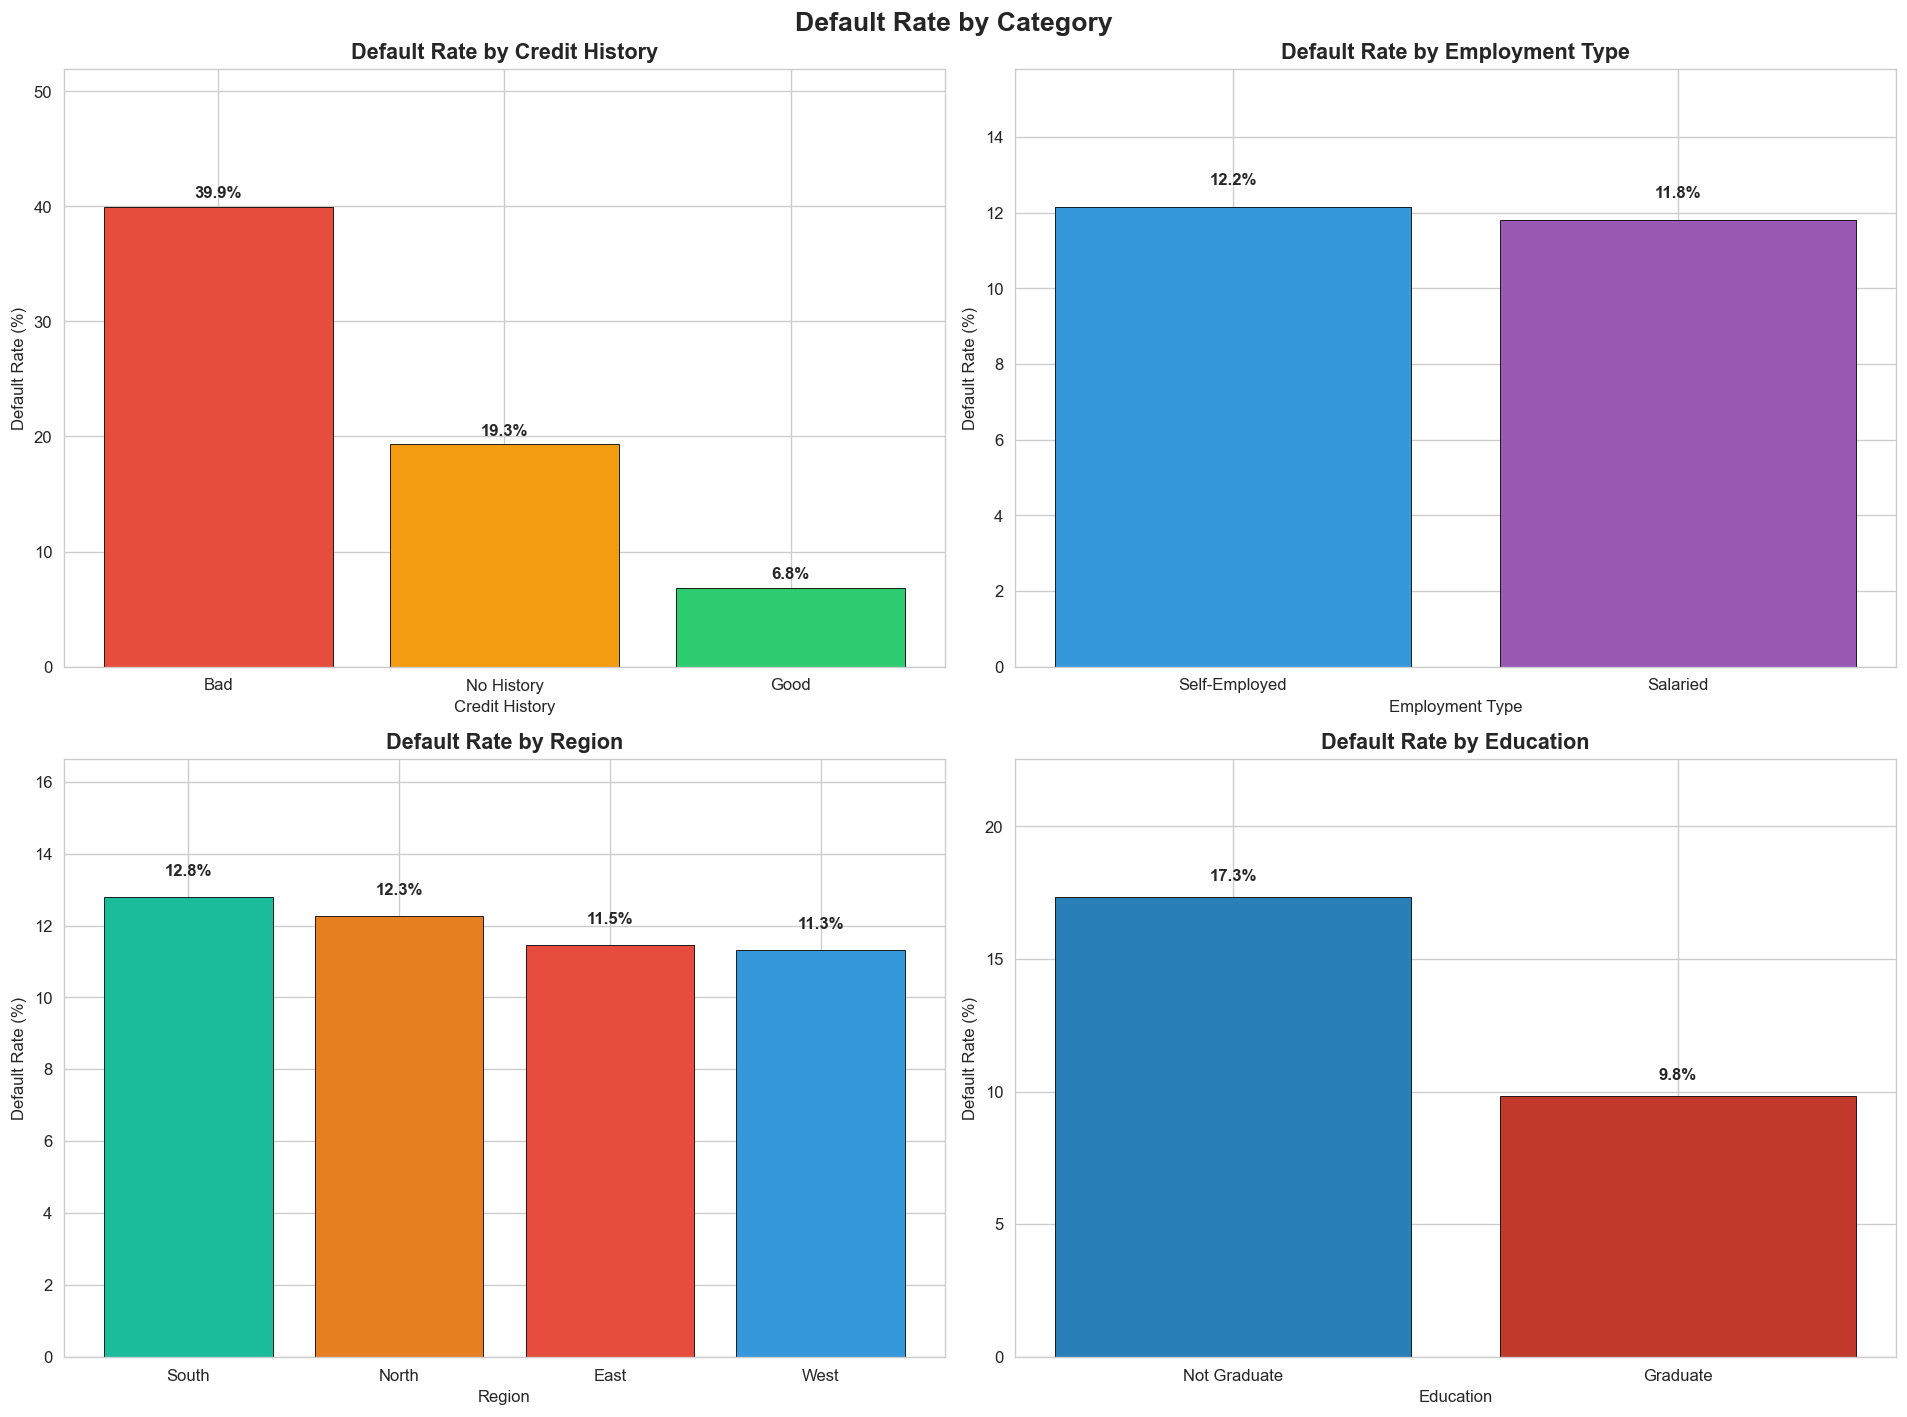

In [7]:
# ---- Plot 2: Default Rate by Categorical Variables ----
fig, axes = plt.subplots(2, 2, figsize = (16, 12))
fig.suptitle("Default Rate by Category", fontsize = 16, fontweight = "bold")

# Helper: Calculate default rate per category
def default_rate(col, ax, title, color):
    rate = df.groupby(col, observed = True)["default_status"].mean() * 100
    rate = rate.sort_values(ascending = False)
    bars = ax.bar(rate.index, rate.values, color = color, edgecolor = "black", linewidth = 0.5)
    ax.set_title(title, fontsize = 13, fontweight = "bold")
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Default Rate (%)")
    ax.set_ylim(0, rate.max() * 1.3)
    # Add percentage labels on top of each bar
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
               f"{val:.1f}%", ha = "center", va = "bottom", fontsize = 10, fontweight = "bold")

default_rate("credit_history", axes[0][0], "Default Rate by Credit History", 
             ["#e74c3c", "#f39c12", "#2ecc71"])
default_rate("employment_type", axes[0][1], "Default Rate by Employment Type", 
             ["#3498db", "#9b59b6"])
default_rate("region", axes[1][0], "Default Rate by Region", 
             ["#1abc9c", "#e67e22", "#e74c3c", "#3498db"])
default_rate("education", axes[1][1], "Default Rate by Education", 
             ["#2980b9", "#c0392b"])

plt.tight_layout()
plt.show()

## 3. Correlation heatmap — which numeric features are related to each other

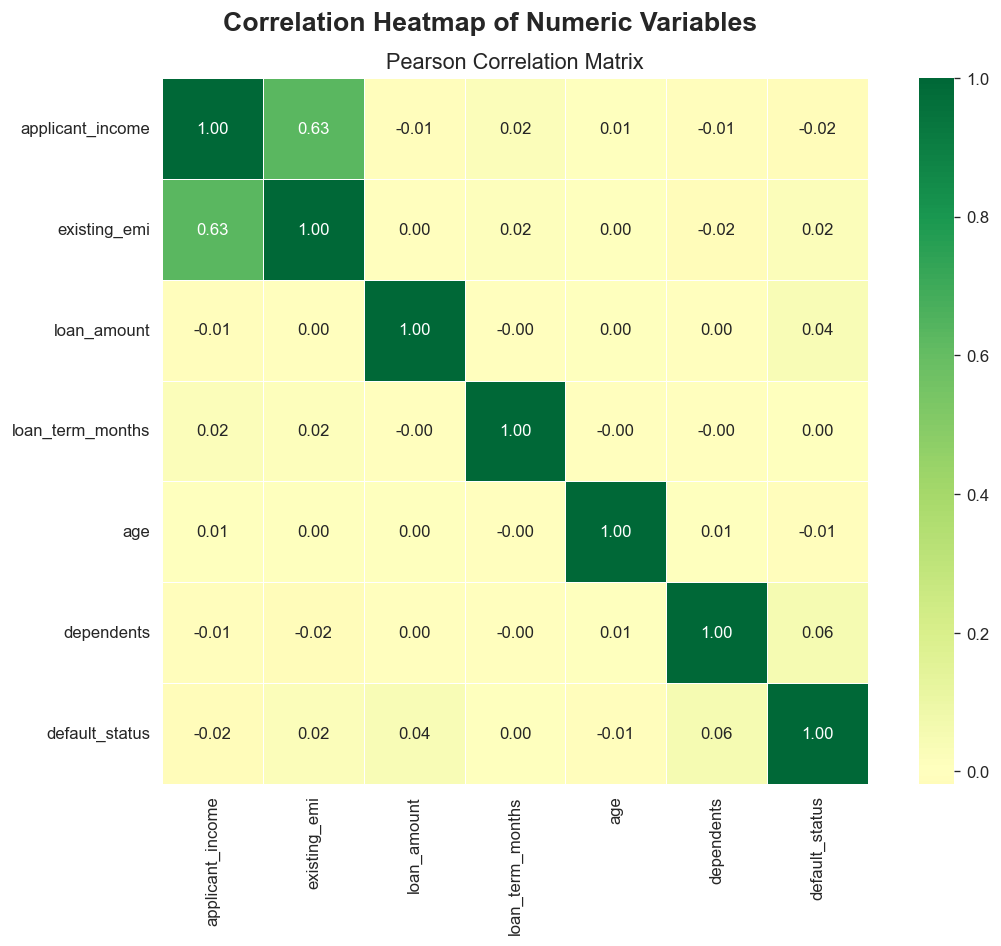

In [8]:
# ---- Plot 3: Correlation Heatmap ----

# Select only numeric columns for correlation
numeric_cols = ["applicant_income", "existing_emi", "loan_amount", "loan_term_months", "age", "dependents", "default_status"]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize = (10, 8))
fig.suptitle("Correlation Heatmap of Numeric Variables", fontsize = 16, fontweight = "bold")

sns.heatmap(
    corr_matrix,
    annot = True,       # show correlation numbers inside each cell
    fmt = ".2f",        # round to 2 decimal places
    cmap = "RdYlGn",    # red = negative, yellow = neutral, green = positive
    center = 0,         # center colormap at 0
    square = True,      # make cells square shaped
    linewidth = 0.5,     # grid lines between cells
    ax = ax
)

ax.set_title("Pearson Correlation Matrix", fontsize = 13)
plt.tight_layout()
plt.show()

## 4. Loan amount vs income scatter — colored by default status

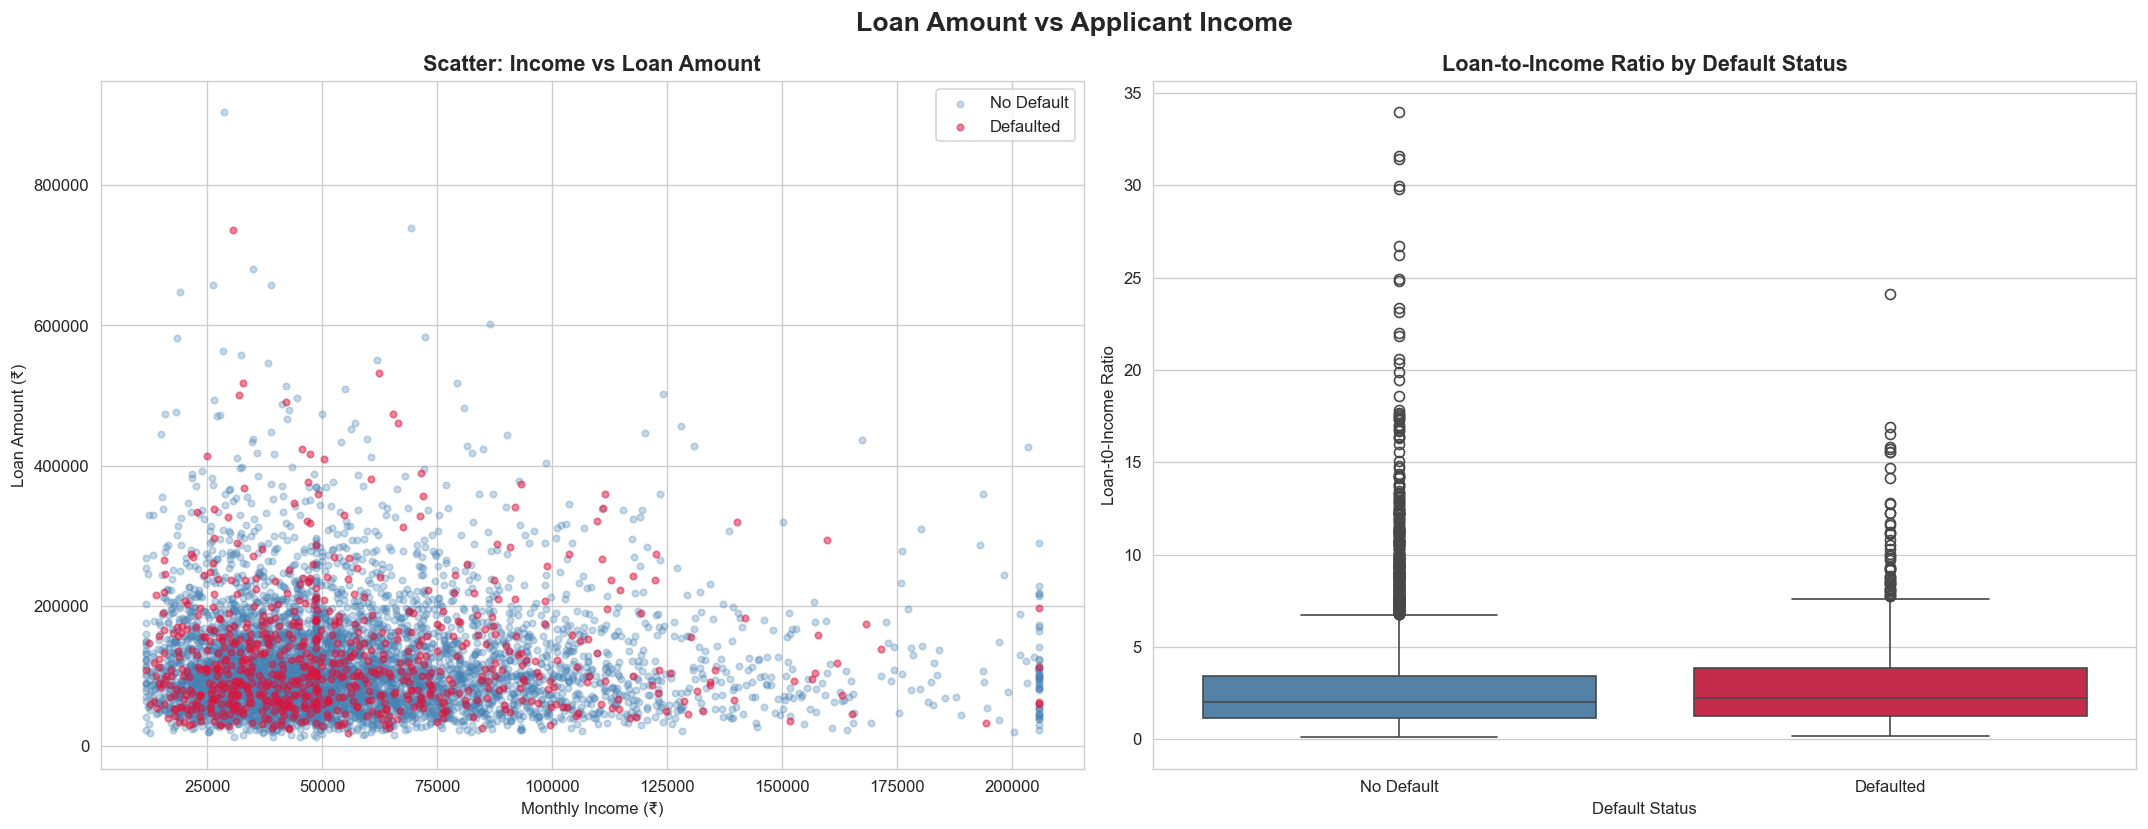


Average Loan-to_Income Ratio: 
default_status
0    2.78
1    3.05
Name: loan_to_income_ratio, dtype: float64


In [9]:
# ---- Plot 4: Loan Amount vs Income scatter (colored by default status) ----
fig, axes = plt.subplots(1, 2, figsize = (18, 7))
fig.suptitle("Loan Amount vs Applicant Income", fontsize = 16, fontweight = "bold")

# Separate defaulters and non-defaulters
defaulted = df[df["default_status"] == 1]
not_defaulted = df[df["default_status"] == 0]

# ---- Left plot: Scatter colored by default status ----
axes[0].scatter(not_defaulted["applicant_income"], not_defaulted["loan_amount"], alpha = 0.3, color = "steelblue", label = "No Default", s = 15)
axes[0].scatter(defaulted["applicant_income"], defaulted["loan_amount"], alpha = 0.5, color = "crimson", label = "Defaulted", s = 15)
axes[0].set_title("Scatter: Income vs Loan Amount", fontsize = 13, fontweight = "bold")
axes[0].set_xlabel("Monthly Income (₹)")
axes[0].set_ylabel("Loan Amount (₹)")
axes[0].legend()

# ---- Right plot: Loan-to-Income ratio boxplot by default status ----
# Create a new feature: loan to income ratio
df["loan_to_income_ratio"] = df["loan_amount"] / df["applicant_income"]

# Convert default_status to string so palette keys match exactly
df["default_label"] = df["default_status"].map({0: "No Default", 1: "Defaulted"})

sns.boxplot(
    x = "default_label",
    y = "loan_to_income_ratio",
    data = df, 
    hue = "default_label",
    palette = {"No Default": "steelblue", "Defaulted": "crimson"},
    legend = False,
    ax = axes[1]
)

axes[1].set_title("Loan-to-Income Ratio by Default Status", fontsize = 13, fontweight = "bold")
axes[1].set_xlabel("Default Status")
axes[1].set_ylabel("Loan-t0-Income Ratio")

plt.tight_layout()
plt.show()

print("\nAverage Loan-to_Income Ratio: ")
print(df.groupby("default_status")["loan_to_income_ratio"].mean().round(2))

## 5. EMI burden analysis — create a new column emi_to_income_ratio and plot against default rate

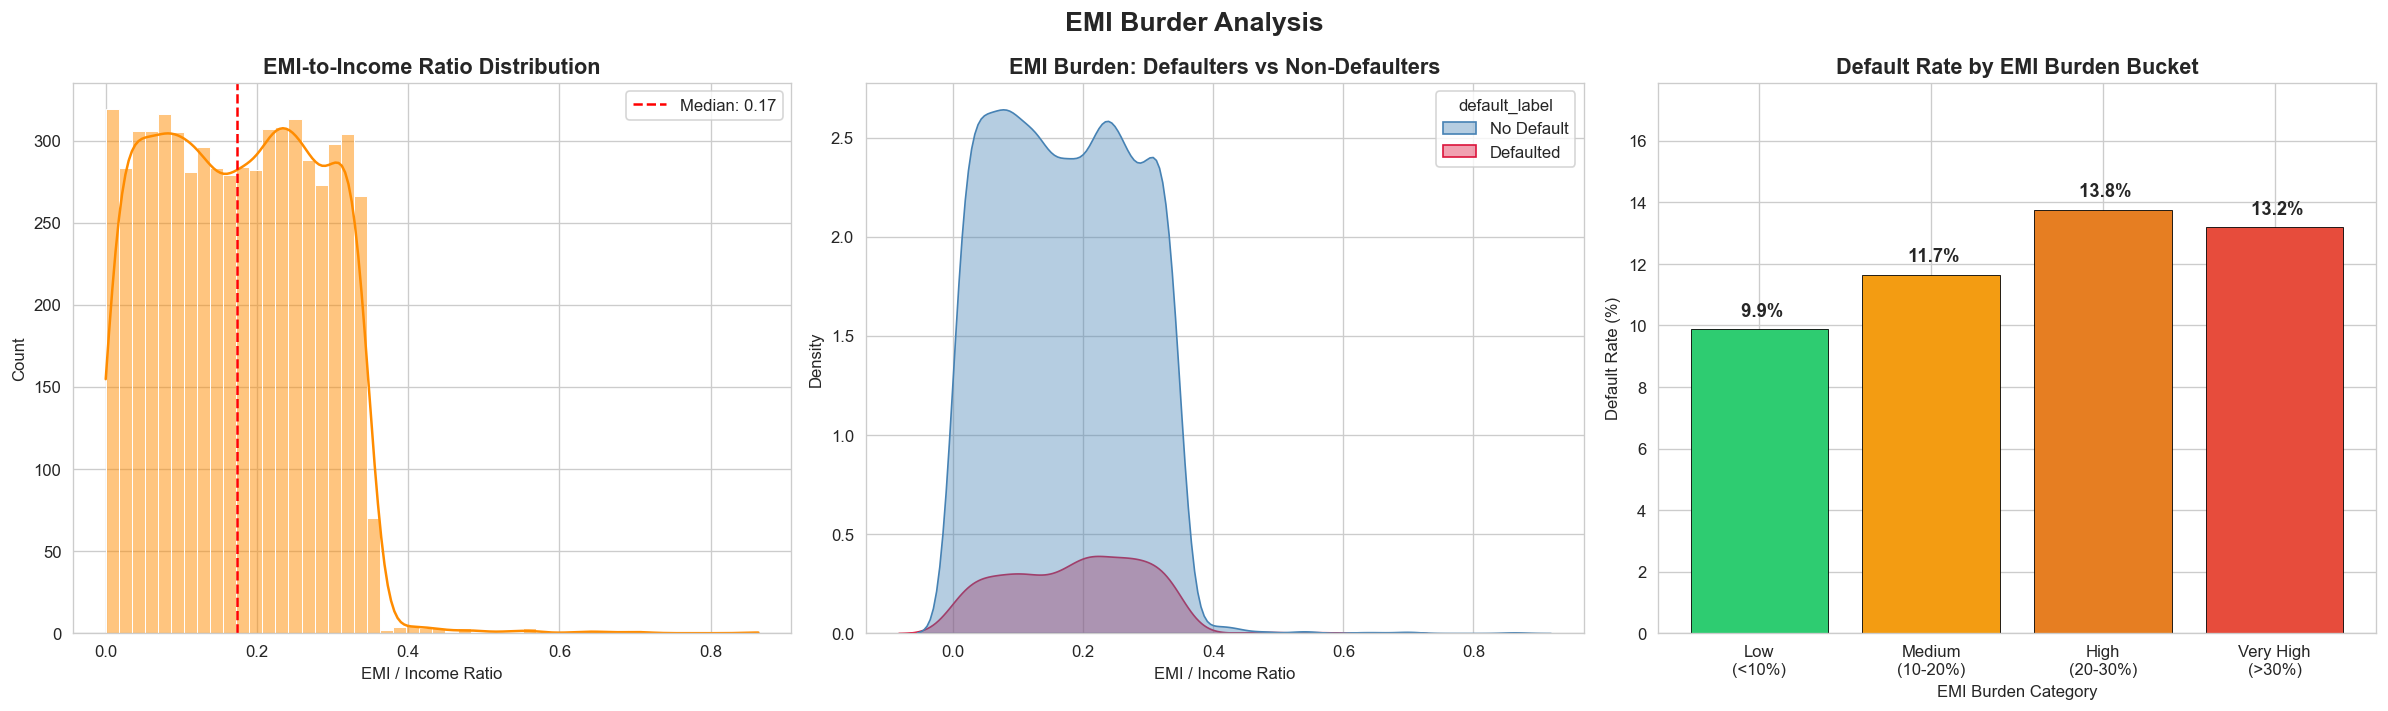


Default rate by EMI burden bucket:
emi_burden_bucket
Low\n(<10%)           9.88
Medium\n(10-20%)     11.65
High\n(20-30%)       13.75
Very High\n(>30%)    13.19
Name: default_status, dtype: float64


In [12]:
# ---- Plot 5: EMI Burden Analysis ----

# Create EMI-to-income ratio column
df["emi_to_income_ratio"] = df["existing_emi"] / df["applicant_income"]

fig, axes = plt.subplots(1, 3, figsize = (20, 6))
fig.suptitle("EMI Burder Analysis", fontsize = 16, fontweight = "bold")

# ---- Left plot: Distribution of EMI-to-income ratio ----
sns.histplot(df["emi_to_income_ratio"], bins = 50, kde = True, color = "darkorange", ax = axes[0])
axes[0].set_title("EMI-to-Income Ratio Distribution", fontsize = 13, fontweight = "bold")
axes[0].set_xlabel("EMI / Income Ratio")
axes[0].set_ylabel("Count")
axes[0].axvline(df["emi_to_income_ratio"].median(), color = "red", linestyle = "--", label = f'Median: {df["emi_to_income_ratio"].median():.2f}')
axes[0].legend()

# ---- Middle plot: EMI burden by default status ----
sns.kdeplot(
    data = df, x = "emi_to_income_ratio",
    hue = "default_label",
    palette = {"No Default": "steelblue", "Defaulted": "crimson"},
    fill = True, alpha = 0.4, ax = axes[1]
)
axes[1].set_title("EMI Burden: Defaulters vs Non-Defaulters", fontsize = 13, fontweight = "bold")
axes[1].set_xlabel("EMI / Income Ratio")
axes[1].set_ylabel("Density")

# ---- Right plot: Default rate by EMI burden bucket ----
# Bin EMI ratio into buckets: Low / Medium / High / Very High
df["emi_burden_bucket"] = pd.cut(
    df["emi_to_income_ratio"],
    bins = [0, 0.1, 0.2, 0.3, 1.0],
    labels = ["Low\n(<10%)", "Medium\n(10-20%)", "High\n(20-30%)", "Very High\n(>30%)"]
)

bucket_default = df.groupby("emi_burden_bucket", observed = True)["default_status"].mean() * 100

bars = axes[2].bar(bucket_default.index, bucket_default.values,
                  color = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"],
                  edgecolor = "black", linewidth = 0.5)
axes[2].set_title("Default Rate by EMI Burden Bucket", fontsize = 13, fontweight = "bold")
axes[2].set_xlabel("EMI Burden Category")
axes[2].set_ylabel("Default Rate (%)")
axes[2].set_ylim(0, bucket_default.max() * 1.3)

for bar, val in zip(bars, bucket_default.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val: .1f}%", ha = "center", va = "bottom",
                fontsize = 11, fontweight = "bold")

plt.tight_layout()
plt.show()

print("\nDefault rate by EMI burden bucket:")
print(bucket_default.round(2))

##### This is genuinely a strong analytical sequence, worth understanding conceptually for your report:

##### 1. Left panel establishes: "here's the overall shape of EMI burden across all applicants, and here's the typical (median) value."

##### 2. Middle panel establishes: "does this shape differ between people who default and people who don't?" — a visual, distributional comparison.

##### 3. Right panel converts that continuous relationship into discrete, actionable buckets with a hard number attached — this is the version
##### that's actually useful for a business/lending decision(e.g. "applicants above 30% EMI burden default at X% rate" is something a 
##### credit policy team could directly act on, unlike a KDE curve).